In [70]:
import os
os.chdir("/home/bluefox/NN/NN-Project1")

In [71]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, metrics, optimizers

In [72]:
max_features = 20000
embedding_dim = 128

In [73]:
input1 = layers.Input(shape=(None,), dtype="int64")
emb = layers.Embedding(max_features, embedding_dim)(input1)
emb = layers.Dropout(0.5)(emb)

In [74]:
x = layers.Conv1D(128, 7, activation="relu", strides=3)(emb)
x = layers.Conv1D(128, 7, activation="relu", strides=3)(x)
x = layers.GlobalMaxPooling1D()(x)

In [75]:
ann = layers.Dense(128, activation="relu")(x)
ann = layers.Dropout(0.5)(ann)
output1 = layers.Dense(1, activation="sigmoid")(ann)

In [76]:
model = models.Model(inputs=input1, outputs=output1)

In [77]:
model.compile(
    optimizer=optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-3,
        beta_1=0.9,
        beta_2=0.999
    ),
    loss= 'binary_crossentropy',
    metrics=['accuracy',metrics.F1Score(threshold=0.5)]
)

In [78]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, None, 128)      │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, None, 128)      │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,806,273 (10.71 MB)

 Trainable params: 2,806,273 (10.71 MB)

 Non-trainable params: 0 (0.00 B)

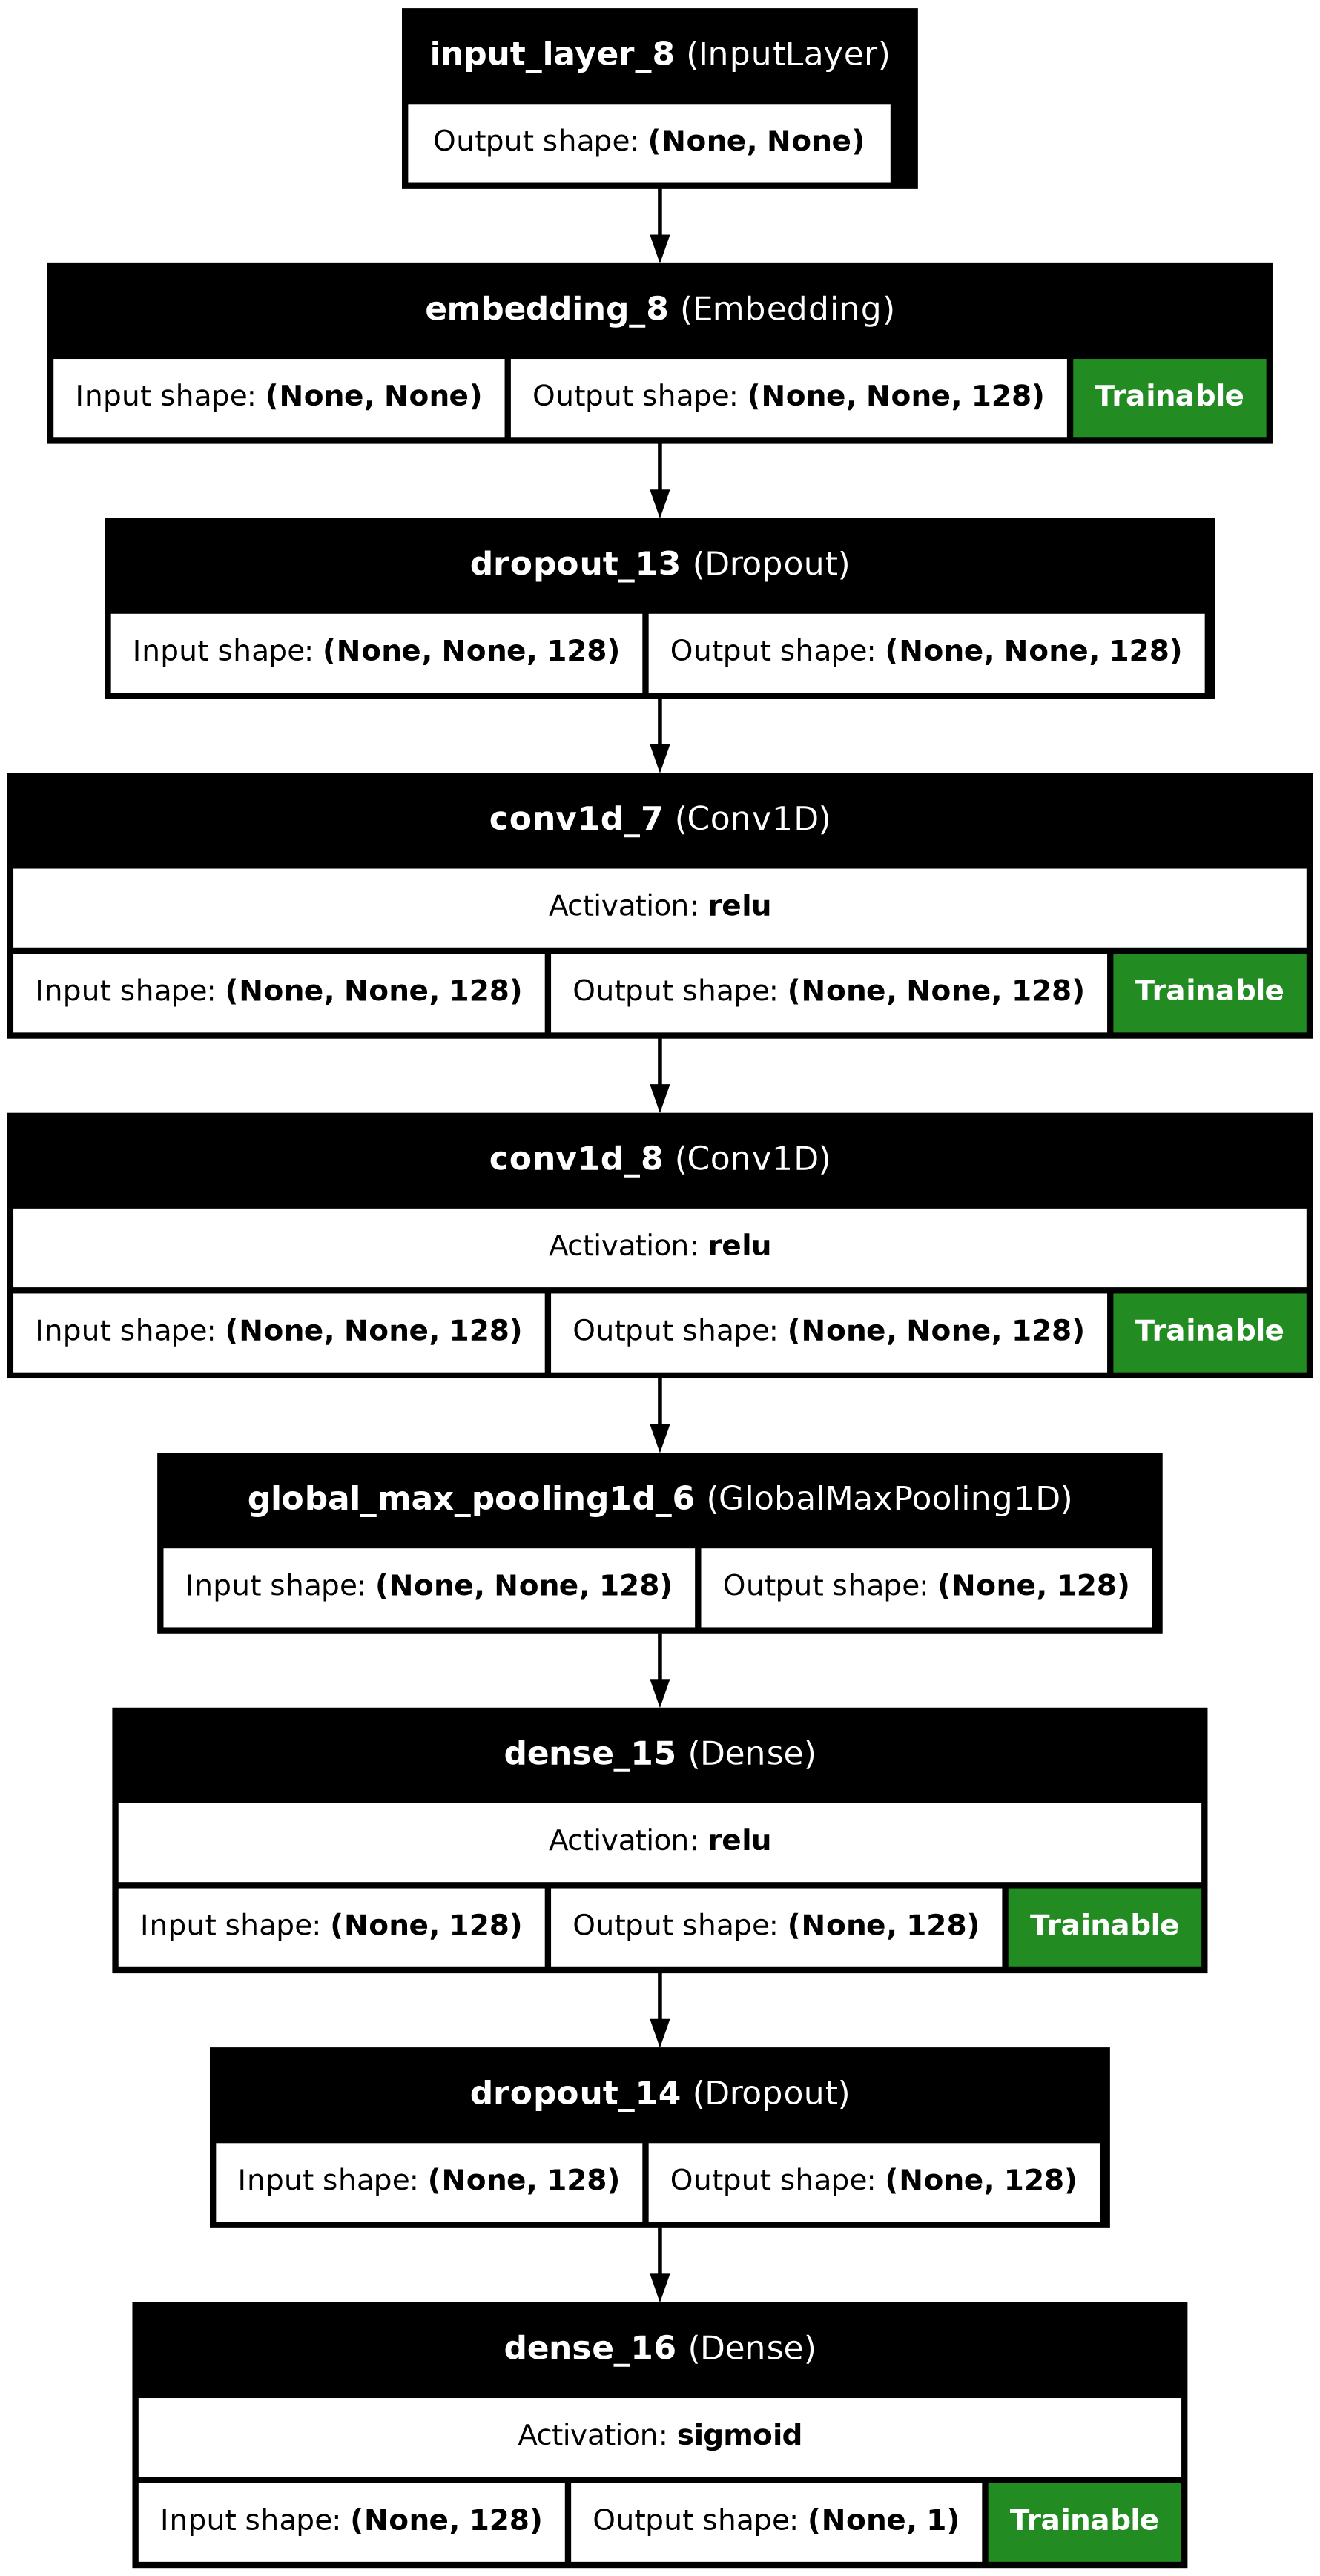

In [79]:
keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True,
    to_file="results/plots/model_arch.png"
)

In [80]:
model.save("models/architecture/untrained_imdb_model.keras")